In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
df= pd.read_csv('Bengaluru_House_Data.csv')

In [38]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [39]:
df.shape

(13320, 9)

In [40]:
df.describe()

,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


<Axes: xlabel='price', ylabel='Count'>

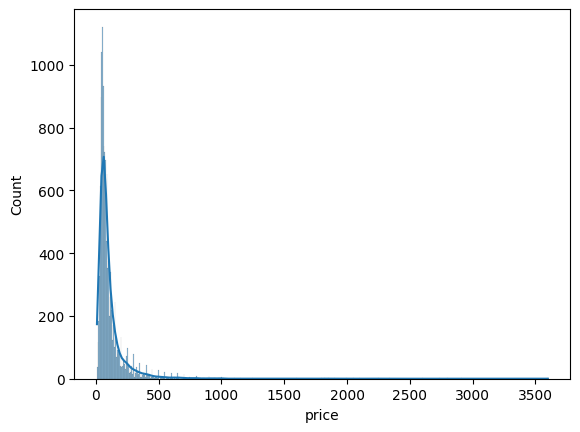

In [41]:
sns.histplot(x='price', data=df, kde= True)

In [42]:
df['price'].describe()

count    13320.000000
mean       112.565627
std        148.971674
min          8.000000
25%         50.000000
50%         72.000000
75%        120.000000
max       3600.000000
Name: price, dtype: float64

In [43]:
df['price'].skew()

8.064468821273252

<Axes: xlabel='price'>

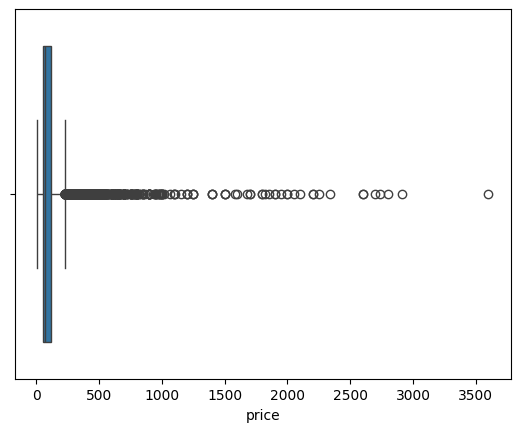

In [44]:
sns.boxplot(data=df, x='price')

# Finding IQR

In [45]:
percentile_25 = df['price'].quantile(0.25)
percentile_75 = df['price'].quantile(0.75)

In [46]:
percentile_25

50.0

In [47]:
percentile_75

120.0

In [48]:
iqr = percentile_75 - percentile_25
iqr

70.0

In [49]:
upper_limit = percentile_75 + 1.5*iqr
lower_limit = percentile_25 - 1.5*iqr

In [50]:
print("Upper Limit",upper_limit)
print("Lower limit",lower_limit)

Upper Limit 225.0
Lower limit -55.0


In [51]:
df[df['price']> upper_limit]

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
7,Super built-up Area,Ready To Move,Rajaji Nagar,4 BHK,Brway G,3300,4.0,NaN,600.0
9,Plot Area,Ready To Move,Gandhi Bazar,6 Bedroom,NaN,1020,6.0,NaN,370.0
11,Plot Area,Ready To Move,Whitefield,4 Bedroom,Prrry M,2785,5.0,3.0,295.0
18,Super built-up Area,Ready To Move,Ramakrishnappa Layout,3 BHK,PeBayle,2770,4.0,2.0,290.0
22,Plot Area,Ready To Move,Thanisandra,4 Bedroom,Soitya,2800,5.0,2.0,380.0
...,...,...,...,...,...,...,...,...,...
13306,Plot Area,Ready To Move,Rajarajeshwari Nagara,4 Bedroom,NaN,1200,5.0,NaN,325.0
13311,Plot Area,Ready To Move,Ramamurthy Nagar,7 Bedroom,NaN,1500,9.0,2.0,250.0
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.0
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.0


In [52]:
df[df['price']<lower_limit]

,area_type,availability,location,size,society,total_sqft,bath,balcony,price


# Trimming

In [53]:
new_df = df[df['price']<upper_limit]
new_df

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
...,...,...,...,...,...,...,...,...,...
13312,Super built-up Area,Ready To Move,Bellandur,2 BHK,NaN,1262,2.0,2.0,47.00
13313,Super built-up Area,Ready To Move,Uttarahalli,3 BHK,Aklia R,1345,2.0,1.0,57.00
13314,Super built-up Area,Ready To Move,Green Glen Layout,3 BHK,SoosePr,1715,3.0,3.0,112.00
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.00


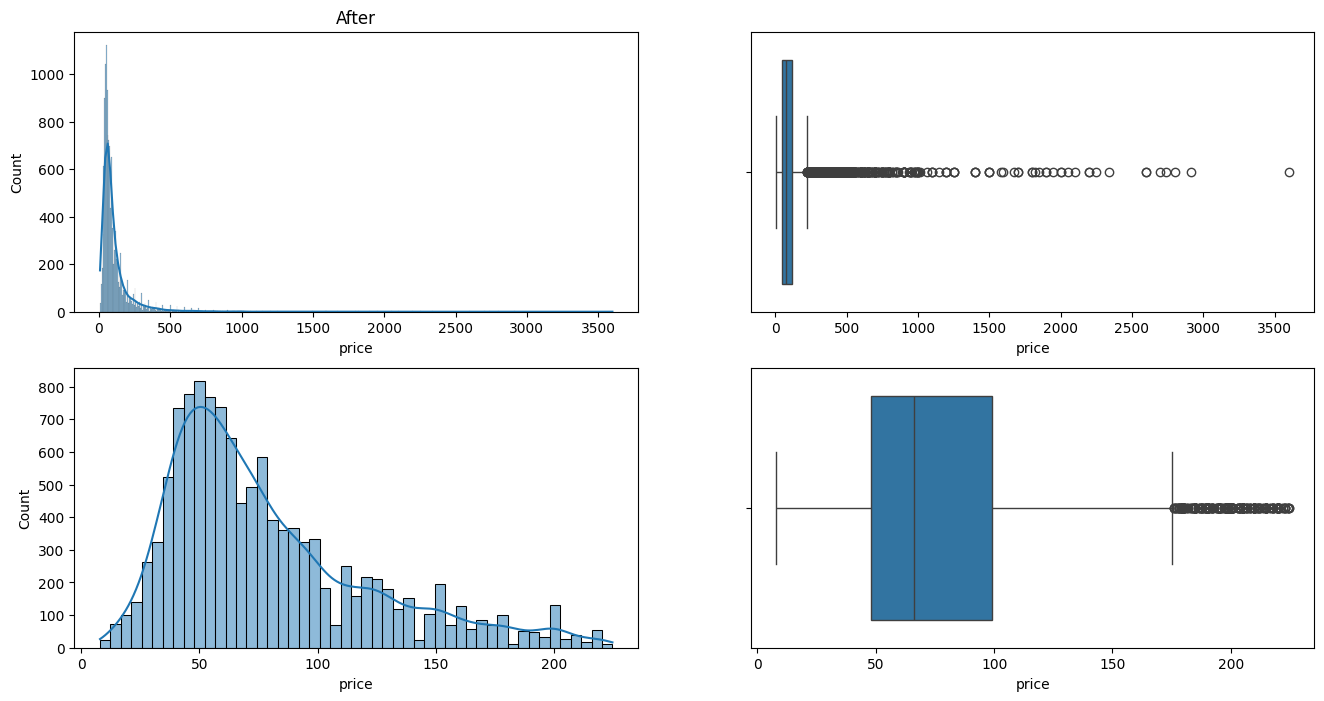

In [ ]:
plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.histplot(df['price'], kde=True)

plt.subplot(2,2,2)
sns.boxplot(x='price', data=df)


plt.subplot(2,2,3)
sns.histplot(new_df['price'], kde=True)

plt.subplot(2,2,4)
sns.boxplot(x='price', data=new_df)

plt.show()

# Capping

In [55]:
new_df_cap = df.copy()

In [56]:
new_df_cap['price']= np.where(
    new_df_cap['price']>upper_limit,
    upper_limit,
    np.where(
        new_df_cap['price']< lower_limit,
        lower_limit,
        new_df_cap['price']
    )
)

In [57]:
new_df_cap.shape

(13320, 9)

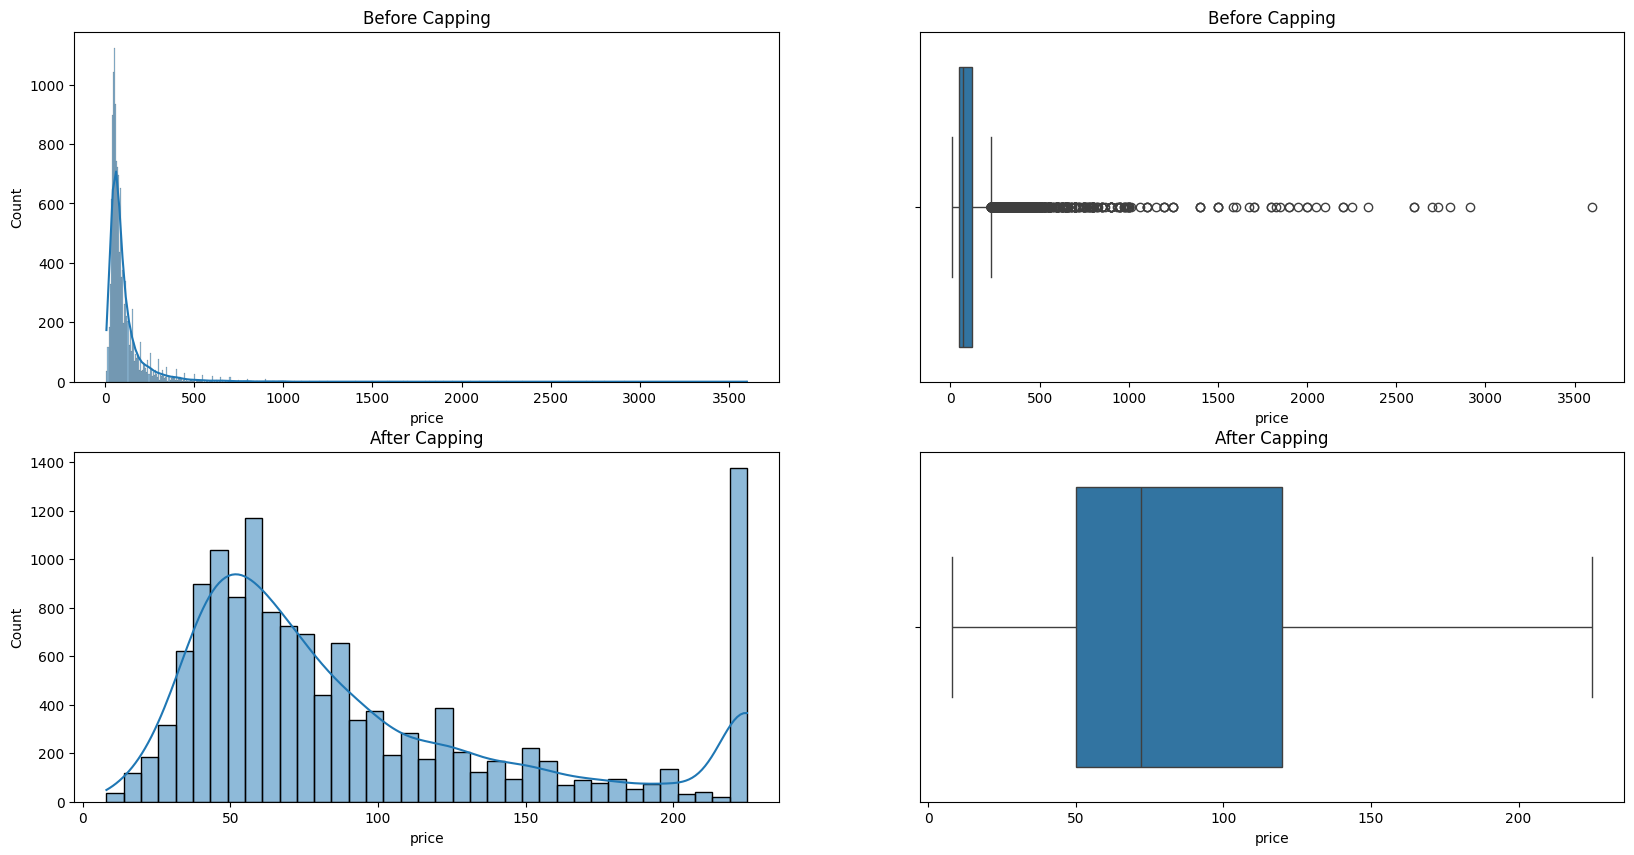

In [71]:
plt.figure(figsize=(20,10))

plt.subplot(2,2,1)
plt.title('Before Capping')
sns.histplot(df['price'], kde=True)

plt.subplot(2,2,2)
plt.title('Before Capping')
sns.boxplot(x='price', data=df)

plt.subplot(2,2,3)
plt.title('After Capping')
sns.histplot(new_df_cap['price'], kde=True)

plt.subplot(2,2,4)
plt.title('After Capping')
sns.boxplot(x='price', data=new_df_cap)

plt.show()